<a href="https://colab.research.google.com/github/skr334/ECG-/blob/main/0709_20250610_V1toV6mask_V6aug_modified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO11-Pose ECG electrode training notebook: V5/V6補強版

目的：既存データだけを使い、V6がラベル付けされている画像を自動抽出し、V5/V6周辺の遮蔽・ノイズ・軽度crop拡張を加えて再学習する。

重要：val/testには拡張画像を入れない。拡張はtrainだけに追加する。これを守らないと、評価が過大になる。


In [20]:
# セル1: 依存関係のインストール
!pip install -U pip setuptools wheel jedi torch torchvision torchaudio "ultralytics>=8.3,<9" --no-cache-dir

# インストール後、必要なら「ランタイムを再起動」してください。


In [21]:
# セル2: バージョン確認・共通import
import os, re, json, math, random, shutil, zipfile, unicodedata, time
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import torch, ultralytics
from ultralytics import YOLO

print("Python      :", os.sys.version.split()[0])
print("Torch       :", torch.__version__, "CUDA available:", torch.cuda.is_available())
print("Ultralytics :", ultralytics.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


Python      : 3.12.13
Torch       : 2.11.0+cu130 CUDA available: True
Ultralytics : 8.4.41


In [6]:
# セル3: 設定
# Google Colabの /content に ecg_data.zip をアップロードしてから実行してください。
ZIP_PATH = Path("/content/卒研：心電図写真.zip")

# 作業フォルダ
RAW_ROOT   = Path("/content/ecg_raw")          # zip展開先
BASE_ROOT  = Path("/content/pose_data_base")   # 元画像のみのYOLO-Poseデータセット
AUG_ROOT   = Path("/content/pose_data_v6aug")  # trainだけ拡張したYOLO-Poseデータセット

# keypoint順序。学習済みラベルと必ず一致させる。
KEYPOINT_ORDER = ['LA','RA','LL','RL','V1','V2','V3','V4','V5','V6']
V1_IDX = KEYPOINT_ORDER.index('V1')
V2_IDX = KEYPOINT_ORDER.index('V2')
V3_IDX = KEYPOINT_ORDER.index('V3')
V4_IDX = KEYPOINT_ORDER.index('V4')
V5_IDX = KEYPOINT_ORDER.index('V5')
V6_IDX = KEYPOINT_ORDER.index('V6')
PRECORDIAL_IDXS = [V1_IDX, V2_IDX, V3_IDX, V4_IDX, V5_IDX, V6_IDX]

# 分割比率。被写体IDがファイル名で分かるなら後段の subject_id_from_path() を修正してください。
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# 拡張倍率。まずは控えめにする。V6だけ10倍などは過学習リスクが高い。
NOISE_AUG_PER_TRAIN_IMAGE = 1           # train全体に軽いノイズ拡張
PRECORDIAL_OCC_AUG_PER_IMAGE = 2        # V1〜V6のいずれかがある画像に単純マスク遮蔽拡張
V6_EXTRA_OCC_AUG_PER_IMAGE   = 2        # V6あり画像に追加でV6重点遮蔽拡張
V6_CROP_AUG_PER_IMAGE        = 1        # V6あり画像に軽いcrop拡張。0にすれば無効。

# 学習設定
PRETRAINED_POSE_MODEL = "yolo11n-pose.pt"  # 最初はnで十分。余力があればs/mをfresh startで比較。
IMGSZ   = 512
EPOCHS  = 150
BATCH   = 8
LR0     = 3e-4


In [7]:
# セル4: zip展開
for p in [RAW_ROOT, BASE_ROOT, AUG_ROOT]:
    if p.exists():
        shutil.rmtree(p)
    p.mkdir(parents=True, exist_ok=True)

assert ZIP_PATH.exists(), f"ZIPが見つかりません: {ZIP_PATH}"
with zipfile.ZipFile(ZIP_PATH) as zf:
    zf.extractall(RAW_ROOT)
print(f"✅ Unzipped to {RAW_ROOT}")
print("JSON files:", list(RAW_ROOT.rglob("*.json"))[:10])


✅ Unzipped to /content/ecg_raw
JSON files: [PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/単色30ｃｍ\u3000TK Supine/TK_30cm_tannsyoku_gyougai.json'), PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/単色1m\u3000TK Stand/TK_1m_tannsyoku_stand.json'), PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/単色1m\u3000TK Supine/TK_1m_tannsyoku_gyougai.json'), PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/単色1m\u3000TK Lateral/TK_1m_tannsyoku_sokugai.json'), PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/雑多30㎝\u3000TK Lateral/TK_30cm_zaxtuta_sokugai.json'), PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/雑多30ｃｍ\u3000TK Supine/TK_30cm_zaxtuta_gyougai.json'), PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/雑多1m\u3000TK Lateral/TK_1m_zaxtuta_sokugai.json'), PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/雑多１ｍ\u3000TK Supine/TK_1m_zaxtuta_gyougai.json'), PosixPath('/content/ecg_raw/卒研：心電図写真/被験者TK\u3000New/雑多1m\u3000TK Stand/TK_1m_zaxtuta_stand.json'), PosixPath('/content/ec

In [8]:
# セル5: VIA JSON → YOLO-Pose形式に変換
# ファイル名の表記揺れにある程度対応する。

def clean_name(fn: str) -> str:
    s = unicodedata.normalize("NFKC", fn)
    s = re.sub(r"\s+", "", s)
    return s.lower()

def build_image_index(root: Path):
    image_index = {}
    for img in root.rglob("*"):
        if img.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            image_index[clean_name(img.name)] = img
            image_index[clean_name(img.stem)] = img
    return image_index

image_index = build_image_index(RAW_ROOT)

def find_image(filename: str):
    return image_index.get(clean_name(filename)) or image_index.get(clean_name(Path(filename).stem))

def get_label(attr: dict):
    # VIAのregion_attributesのどこかに LA/RA/.../V6 が入っている想定
    if not isinstance(attr, dict):
        return None
    for v in attr.values():
        if isinstance(v, str) and v in KEYPOINT_ORDER:
            return v
    for k in attr.keys():
        if k in KEYPOINT_ORDER:
            return k
    for v in attr.values():
        if isinstance(v, dict):
            r = get_label(v)
            if r:
                return r
    return None

def shape_center(sa: dict):
    # VIAのrect/circle/point等に対応
    name = sa.get('name', '')
    if 'x' in sa and 'y' in sa and 'width' in sa and 'height' in sa:
        return sa['x'] + sa['width'] / 2, sa['y'] + sa['height'] / 2, [sa['x'], sa['y'], sa['x'] + sa['width'], sa['y'] + sa['height']]
    if 'cx' in sa and 'cy' in sa:
        r = float(sa.get('r', 3))
        return sa['cx'], sa['cy'], [sa['cx'] - r, sa['cy'] - r, sa['cx'] + r, sa['cy'] + r]
    if 'x' in sa and 'y' in sa:
        r = 3
        return sa['x'], sa['y'], [sa['x'] - r, sa['y'] - r, sa['x'] + r, sa['y'] + r]
    return None, None, None

def visible_bbox_from_kpts(kpts, margin=0.03):
    # kpts: normalized [x,y,v]
    pts = [(x, y) for x, y, v in kpts if v > 0]
    if not pts:
        return [0.5, 0.5, 1.0, 1.0]
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    x1 = max(0.0, min(xs) - margin)
    y1 = max(0.0, min(ys) - margin)
    x2 = min(1.0, max(xs) + margin)
    y2 = min(1.0, max(ys) + margin)
    return [(x1+x2)/2, (y1+y2)/2, max(1e-6, x2-x1), max(1e-6, y2-y1)]

base_img_dir = BASE_ROOT / 'images_all'
base_lbl_dir = BASE_ROOT / 'labels_all'
base_img_dir.mkdir(parents=True, exist_ok=True)
base_lbl_dir.mkdir(parents=True, exist_ok=True)

converted = 0
missing = 0
for jp in RAW_ROOT.rglob("*.json"):
    with open(jp, 'r', encoding='utf-8') as f:
        via = json.load(f)
    for meta in via.get('_via_img_metadata', {}).values():
        img_path = find_image(meta.get('filename', ''))
        if img_path is None:
            missing += 1
            print("⚠️ Image not found for", meta.get('filename'))
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            missing += 1
            print("⚠️ Could not read", img_path)
            continue
        h, w = img.shape[:2]
        kpts = [[0.0, 0.0, 0.0] for _ in KEYPOINT_ORDER]
        for r in meta.get('regions', []):
            label = get_label(r.get('region_attributes', {}))
            if label not in KEYPOINT_ORDER:
                continue
            cx, cy, box = shape_center(r.get('shape_attributes', {}))
            if cx is None:
                continue
            idx = KEYPOINT_ORDER.index(label)
            kpts[idx] = [float(cx)/w, float(cy)/h, 1.0]
        if not any(k[2] > 0 for k in kpts):
            continue

        bbox = visible_bbox_from_kpts(kpts, margin=0.04)
        line = [0] + bbox + [c for kp in kpts for c in kp]

        # 同名衝突を避ける
        out_stem = f"{converted:06d}_{img_path.stem}"
        out_img = base_img_dir / f"{out_stem}{img_path.suffix.lower()}"
        out_lbl = base_lbl_dir / f"{out_stem}.txt"
        shutil.copy2(img_path, out_img)
        out_lbl.write_text(" ".join(f"{v:.6f}" for v in line))
        converted += 1

print(f"✅ Converted: {converted} images")
print(f"⚠️ Missing/unreadable: {missing}")


⚠️ Image not found for LINE_ALBUM_ゆーき立位しろ_250428_1.jpg
⚠️ Image not found for LINE_ALBUM_ゆーき立位しろ_250428_2.jpg
⚠️ Image not found for LINE_ALBUM_ありま単色仰臥位30cm_250602_3.jpg
⚠️ Image not found for LINE_ALBUM_ありま単色仰臥位30cm_250602_4.jpg
✅ Converted: 2670 images
⚠️ Missing/unreadable: 4


In [9]:
# セル6: V6が見える/ラベル付けされている画像を、ファイル名ではなくラベルから自動判定する
# YOLO-Pose label: class cx cy w h + 10*(x y v)

def read_label(label_path: Path):
    vals = list(map(float, label_path.read_text().strip().split()))
    if len(vals) < 5 + 3*len(KEYPOINT_ORDER):
        raise ValueError(f"label length is too short: {label_path}")
    return vals

def has_keypoint(label_path: Path, idx: int):
    vals = read_label(label_path)
    v = vals[5 + idx*3 + 2]
    return v > 0

def label_counts(label_dir: Path):
    c = Counter()
    files = list(label_dir.glob("*.txt"))
    for lp in files:
        vals = read_label(lp)
        for i, name in enumerate(KEYPOINT_ORDER):
            if vals[5 + i*3 + 2] > 0:
                c[name] += 1
    return c, len(files)

counts, n_files = label_counts(base_lbl_dir)
print("Total labeled images:", n_files)
print("Keypoint counts:")
for name in KEYPOINT_ORDER:
    print(f"  {name}: {counts[name]}")

v6_labels = [lp for lp in base_lbl_dir.glob("*.txt") if has_keypoint(lp, V6_IDX)]
print(f"\n✅ V6あり画像数: {len(v6_labels)}")
print("例:", [p.name for p in v6_labels[:10]])


Total labeled images: 2670
Keypoint counts:
  LA: 1501
  RA: 1501
  LL: 568
  RL: 570
  V1: 2526
  V2: 2493
  V3: 2512
  V4: 2335
  V5: 1583
  V6: 554

✅ V6あり画像数: 554
例: ['002180_LINE_ALBUM_ありま雑多側臥位1m_250602_1.txt', '000530_LINE_ALBUM_しょーくん立位雑多30cm_250602_11.txt', '002205_LINE_ALBUM_ありま単色立位1m_250602_17.txt', '000062_LINE_ALBUM_つむ雑多30側臥位_250428_5.txt', '001712_LINE_ALBUM_雑多立位_250414_10.txt', '000198_LINE_ALBUM_つむ雑多2m_250428_11.txt', '000858_LINE_ALBUM_としとし仰臥位30センチ青_250416_12.txt', '001651_LINE_ALBUM_青1mそくがいい_250414_1.txt', '000809_LINE_ALBUM_としとしざった(_250416_18.txt', '000717_LINE_ALBUM_としとし白背景_250416_11.txt']


In [10]:
# セル7: train/val/test分割
# 重要：拡張はtrainにだけ追加する。val/testには元画像だけを入れる。
# 被写体IDがファイル名から分かる場合は subject_id_from_path() を修正する。

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def matching_image_for_label(label_path: Path, img_dir: Path):
    stem = label_path.stem
    for ext in IMG_EXTS:
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"No image for {label_path}")

def subject_id_from_path(img_path: Path):
    # 分からない場合は画像単位分割。
    # 例: ファイル名が subject01_xxx.jpg なら return img_path.stem.split('_')[0]
    return img_path.stem

items = []
for lp in sorted(base_lbl_dir.glob("*.txt")):
    ip = matching_image_for_label(lp, base_img_dir)
    items.append((ip, lp, subject_id_from_path(ip)))

# subject単位でsplit。同じsubject_idが同じ集合に入る。
by_subj = defaultdict(list)
for item in items:
    by_subj[item[2]].append(item)
subjects = list(by_subj.keys())
random.shuffle(subjects)

n = len(subjects)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
train_subjects = set(subjects[:n_train])
val_subjects   = set(subjects[n_train:n_train+n_val])
test_subjects  = set(subjects[n_train+n_val:])

splits = {'train': [], 'val': [], 'test': []}
for subj, its in by_subj.items():
    if subj in train_subjects:
        splits['train'].extend(its)
    elif subj in val_subjects:
        splits['val'].extend(its)
    else:
        splits['test'].extend(its)

# BASE_ROOTをYOLO形式に整える
for sub in ['images/train','images/val','images/test','labels/train','labels/val','labels/test']:
    d = BASE_ROOT / sub
    if d.exists(): shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

for split_name, split_items in splits.items():
    for ip, lp, subj in split_items:
        shutil.copy2(ip, BASE_ROOT/'images'/split_name/ip.name)
        shutil.copy2(lp, BASE_ROOT/'labels'/split_name/lp.name)

base_yaml = f"""path: {BASE_ROOT}
train: images/train
val: images/val
test: images/test
kpt_shape: [10,3]
names: ['person']
"""
(BASE_ROOT/'data.yaml').write_text(base_yaml)

for split_name in ['train','val','test']:
    c, nf = label_counts(BASE_ROOT/'labels'/split_name)
    print(f"{split_name}: images={len(list((BASE_ROOT/'images'/split_name).glob('*')))}, labels={nf}, V5={c['V5']}, V6={c['V6']}")
print("✅ Created", BASE_ROOT/'data.yaml')


train: images=2136, labels=2136, V5=1266, V6=456
val: images=267, labels=267, V5=152, V6=37
test: images=267, labels=267, V5=165, V6=61
✅ Created /content/pose_data_base/data.yaml


In [12]:
# セル8: 拡張関数。座標を変えない遮蔽/ノイズと、座標変換ありの軽度cropを作る。

def load_image_and_label(img_path: Path, lbl_path: Path):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    vals = read_label(lbl_path)
    return img, vals

def get_kpt_pixel(vals, idx, w, h):
    x = vals[5 + idx*3]
    y = vals[5 + idx*3 + 1]
    v = vals[5 + idx*3 + 2]
    if v <= 0:
        return None
    return int(round(x*w)), int(round(y*h))

def visible_keypoint_indices(vals, idxs):
    visible = []
    for idx in idxs:
        v = vals[5 + idx*3 + 2]
        if v > 0:
            visible.append(idx)
    return visible

def has_any_keypoint(lp: Path, idxs):
    vals = read_label(lp)
    return len(visible_keypoint_indices(vals, idxs)) > 0

def add_noise_blur_brightness(img):
    out = img.copy()
    # 明度・コントラスト
    alpha = random.uniform(0.85, 1.15)
    beta = random.randint(-22, 22)
    out = cv2.convertScaleAbs(out, alpha=alpha, beta=beta)

    # Gaussian noise
    if random.random() < 0.60:
        sigma = random.uniform(3, 10)
        noise = np.random.normal(0, sigma, out.shape).astype(np.int16)
        out = np.clip(out.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # blur
    if random.random() < 0.35:
        k = random.choice([3, 5])
        out = cv2.GaussianBlur(out, (k, k), 0)

    # JPEG圧縮風
    if random.random() < 0.35:
        q = random.randint(45, 85)
        ok, enc = cv2.imencode('.jpg', out, [int(cv2.IMWRITE_JPEG_QUALITY), q])
        if ok:
            out = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return out

def _draw_simple_mask_occlusion(img, center, strength="moderate"):
    """楕円＋細長い矩形で、手・前腕・影に近い単純マスク遮蔽を作る。
    幾何変換はしないので、ラベル座標はそのまま使える。
    """
    h, w = img.shape[:2]
    out = img.copy()
    overlay = out.copy()
    cx, cy = center

    # 完全遮蔽より、部分遮蔽を中心にする。
    if strength == "mild":
        dx = random.randint(-24, 24)
        dy = random.randint(-24, 24)
        rx = random.randint(max(6, w//55), max(10, w//28))
        ry = random.randint(max(10, h//55), max(18, h//24))
        alpha = random.uniform(0.35, 0.62)
    else:
        dx = random.randint(-35, 35)
        dy = random.randint(-35, 35)
        rx = random.randint(max(8, w//45), max(14, w//20))
        ry = random.randint(max(12, h//45), max(24, h//14))
        alpha = random.uniform(0.42, 0.74)

    center = (int(np.clip(cx + dx, 0, w-1)), int(np.clip(cy + dy, 0, h-1)))
    angle = random.randint(-60, 60)

    # BGR。手・前腕・影っぽいが、外部画像は使わない。
    color = random.choice([
        (70, 85, 110), (85, 110, 140), (105, 135, 165),
        (45, 55, 75), (125, 150, 180)
    ])
    cv2.ellipse(overlay, center, (rx, ry), angle, 0, 360, color, -1)
    out = cv2.addWeighted(overlay, alpha, out, 1-alpha, 0)

    # 追加で細い斜め矩形を入れることがある。前腕/指の疑似遮蔽。
    if random.random() < 0.40:
        overlay = out.copy()
        length = random.randint(max(24, w//10), max(40, w//3))
        thickness = random.randint(max(6, w//70), max(12, w//32))
        theta = np.deg2rad(random.randint(-60, 60))
        ux, uy = np.cos(theta), np.sin(theta)
        vx, vy = -uy, ux
        cx2, cy2 = center
        pts = np.array([
            [cx2 - ux*length/2 - vx*thickness/2, cy2 - uy*length/2 - vy*thickness/2],
            [cx2 + ux*length/2 - vx*thickness/2, cy2 + uy*length/2 - vy*thickness/2],
            [cx2 + ux*length/2 + vx*thickness/2, cy2 + uy*length/2 + vy*thickness/2],
            [cx2 - ux*length/2 + vx*thickness/2, cy2 - uy*length/2 + vy*thickness/2],
        ], dtype=np.int32)
        cv2.fillPoly(overlay, [pts], color)
        out = cv2.addWeighted(overlay, random.uniform(0.30, 0.58), out, 0.60, 0)
    return out

def add_precordial_occlusion(img, vals, target_idxs=None, prefer_v6=False):
    """V1〜V6の見えている点のいずれかに単純マスク遮蔽を加える。
    prefer_v6=Trueなら、V6が見えている場合はV6を優先する。
    """
    h, w = img.shape[:2]
    if target_idxs is None:
        target_idxs = PRECORDIAL_IDXS

    visible = visible_keypoint_indices(vals, target_idxs)
    if not visible:
        return img

    if prefer_v6 and V6_IDX in visible:
        idx = V6_IDX
    else:
        idx = random.choice(visible)

    target = get_kpt_pixel(vals, idx, w, h)
    if target is None:
        return img

    strength = "moderate" if idx in [V5_IDX, V6_IDX] else random.choice(["mild", "moderate"])
    return _draw_simple_mask_occlusion(img, target, strength=strength)

def write_label(path: Path, vals):
    path.write_text(" ".join(f"{v:.6f}" for v in vals))

def recompute_bbox(vals):
    kpts = []
    for i in range(len(KEYPOINT_ORDER)):
        x, y, v = vals[5+i*3], vals[5+i*3+1], vals[5+i*3+2]
        kpts.append([x, y, v])
    bbox = visible_bbox_from_kpts(kpts, margin=0.04)
    vals[1:5] = bbox
    return vals

def crop_around_v6(img, vals, min_keep=0.78):
    # V6が入るように軽度cropする。全体構造を壊さないため、元画像の78%以上を残す。
    h, w = img.shape[:2]
    v6 = get_kpt_pixel(vals, V6_IDX, w, h)
    if v6 is None:
        return None, None
    crop_w = int(w * random.uniform(min_keep, 0.95))
    crop_h = int(h * random.uniform(min_keep, 0.95))
    vx, vy = v6

    # V6が端寄りに残るよう、必ず中央固定にはしない。
    x1_min = max(0, vx - crop_w + random.randint(10, max(11, crop_w//4)))
    x1_max = min(vx - random.randint(10, max(11, crop_w//5)), w - crop_w)
    if x1_min > x1_max:
        x1 = int(np.clip(vx - crop_w*0.75, 0, w-crop_w))
    else:
        x1 = random.randint(int(x1_min), int(x1_max))

    y1_min = max(0, vy - int(crop_h*0.80))
    y1_max = min(vy - int(crop_h*0.20), h - crop_h)
    if y1_min > y1_max:
        y1 = int(np.clip(vy - crop_h*0.5, 0, h-crop_h))
    else:
        y1 = random.randint(int(y1_min), int(y1_max))

    x2, y2 = x1 + crop_w, y1 + crop_h
    cropped = img[y1:y2, x1:x2].copy()

    new_vals = vals.copy()
    for i in range(len(KEYPOINT_ORDER)):
        x, y, v = vals[5+i*3], vals[5+i*3+1], vals[5+i*3+2]
        if v <= 0:
            continue
        px, py = x*w, y*h
        if x1 <= px <= x2 and y1 <= py <= y2:
            new_vals[5+i*3] = (px - x1) / crop_w
            new_vals[5+i*3+1] = (py - y1) / crop_h
            new_vals[5+i*3+2] = v
        else:
            new_vals[5+i*3] = 0.0
            new_vals[5+i*3+1] = 0.0
            new_vals[5+i*3+2] = 0.0
    new_vals = recompute_bbox(new_vals)
    return cropped, new_vals


In [13]:
# セル9: trainだけ拡張したデータセットを作成
# V6が見えるデータは、ラベル内のV6 visibility > 0 で判定する。
# 単純マスク遮蔽はV1〜V6の見えている点に適用する。V6は追加で重点遮蔽する。

# AUG_ROOTを初期化
if AUG_ROOT.exists():
    shutil.rmtree(AUG_ROOT)
for sub in ['images/train','images/val','images/test','labels/train','labels/val','labels/test']:
    (AUG_ROOT/sub).mkdir(parents=True, exist_ok=True)

# 元データを全splitにコピー
for split in ['train','val','test']:
    for ip in (BASE_ROOT/'images'/split).glob('*'):
        shutil.copy2(ip, AUG_ROOT/'images'/split/ip.name)
    for lp in (BASE_ROOT/'labels'/split).glob('*.txt'):
        shutil.copy2(lp, AUG_ROOT/'labels'/split/lp.name)

# trainの画像・ラベル一覧
train_labels = sorted((BASE_ROOT/'labels'/'train').glob('*.txt'))

def image_in_base_train_for_label(lp):
    return matching_image_for_label(lp, BASE_ROOT/'images'/'train')

created_noise = 0
created_precordial_occ = 0
created_v6_extra_occ = 0
created_crop = 0

# 1) train全体に軽いノイズ拡張
for lp in train_labels:
    ip = image_in_base_train_for_label(lp)
    img, vals = load_image_and_label(ip, lp)
    for i in range(NOISE_AUG_PER_TRAIN_IMAGE):
        aug = add_noise_blur_brightness(img)
        stem = f"{ip.stem}_noise_{i}"
        cv2.imwrite(str(AUG_ROOT/'images'/'train'/f"{stem}.jpg"), aug)
        write_label(AUG_ROOT/'labels'/'train'/f"{stem}.txt", vals)
        created_noise += 1

# 2) V1〜V6のいずれかがある画像を自動抽出し、単純マスク遮蔽・ノイズ拡張
precordial_train_labels = [lp for lp in train_labels if has_any_keypoint(lp, PRECORDIAL_IDXS)]
print(f"train内V1〜V6いずれかあり画像: {len(precordial_train_labels)} / {len(train_labels)}")

for lp in precordial_train_labels:
    ip = image_in_base_train_for_label(lp)
    img, vals = load_image_and_label(ip, lp)
    for i in range(PRECORDIAL_OCC_AUG_PER_IMAGE):
        aug = add_precordial_occlusion(img, vals, target_idxs=PRECORDIAL_IDXS, prefer_v6=False)
        aug = add_noise_blur_brightness(aug)
        stem = f"{ip.stem}_precordial_occ_{i}"
        cv2.imwrite(str(AUG_ROOT/'images'/'train'/f"{stem}.jpg"), aug)
        write_label(AUG_ROOT/'labels'/'train'/f"{stem}.txt", vals)  # 幾何変換なしなのでラベルはそのまま
        created_precordial_occ += 1

# 3) V6あり画像に追加でV6重点遮蔽・ノイズ拡張
v6_train_labels = [lp for lp in train_labels if has_keypoint(lp, V6_IDX)]
print(f"train内V6あり画像: {len(v6_train_labels)} / {len(train_labels)}")

for lp in v6_train_labels:
    ip = image_in_base_train_for_label(lp)
    img, vals = load_image_and_label(ip, lp)
    for i in range(V6_EXTRA_OCC_AUG_PER_IMAGE):
        aug = add_precordial_occlusion(img, vals, target_idxs=PRECORDIAL_IDXS, prefer_v6=True)
        aug = add_noise_blur_brightness(aug)
        stem = f"{ip.stem}_v6extra_occ_{i}"
        cv2.imwrite(str(AUG_ROOT/'images'/'train'/f"{stem}.jpg"), aug)
        write_label(AUG_ROOT/'labels'/'train'/f"{stem}.txt", vals)  # 幾何変換なしなのでラベルはそのまま
        created_v6_extra_occ += 1

# 4) V6あり画像に軽度crop拡張。これは座標変換あり。
for lp in v6_train_labels:
    ip = image_in_base_train_for_label(lp)
    img, vals = load_image_and_label(ip, lp)
    for i in range(V6_CROP_AUG_PER_IMAGE):
        cropped, new_vals = crop_around_v6(img, vals)
        if cropped is None:
            continue
        cropped = add_noise_blur_brightness(cropped)
        stem = f"{ip.stem}_v6crop_{i}"
        cv2.imwrite(str(AUG_ROOT/'images'/'train'/f"{stem}.jpg"), cropped)
        write_label(AUG_ROOT/'labels'/'train'/f"{stem}.txt", new_vals)
        created_crop += 1

aug_yaml = f"""path: {AUG_ROOT}
train: images/train
val: images/val
test: images/test
kpt_shape: [10,3]
names: ['person']
"""
(AUG_ROOT/'data.yaml').write_text(aug_yaml)

print("✅ Augmentation created")
print("  noise:", created_noise)
print("  precordial V1-V6 occlusion:", created_precordial_occ)
print("  v6 extra occlusion:", created_v6_extra_occ)
print("  v6 crop:", created_crop)

for split in ['train','val','test']:
    c, nf = label_counts(AUG_ROOT/'labels'/split)
    print(f"{split}: images={len(list((AUG_ROOT/'images'/split).glob('*')))}, labels={nf}, V1={c['V1']}, V2={c['V2']}, V3={c['V3']}, V4={c['V4']}, V5={c['V5']}, V6={c['V6']}")
print("✅ Created", AUG_ROOT/'data.yaml')


train内V1〜V6いずれかあり画像: 2120 / 2136
train内V6あり画像: 456 / 2136
✅ Augmentation created
  noise: 2136
  precordial V1-V6 occlusion: 4240
  v6 extra occlusion: 912
  v6 crop: 456
train: images=9880, labels=9880, V1=9313, V2=9065, V3=9281, V4=8808, V5=6414, V6=3189
val: images=267, labels=267, V1=247, V2=249, V3=253, V4=232, V5=152, V6=37
test: images=267, labels=267, V1=253, V2=249, V3=248, V4=239, V5=165, V6=61
✅ Created /content/pose_data_v6aug/data.yaml


samples: 12


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31179 (\N{CJK UNIFIED IDEOGRAPH-79CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23665 (\N{CJK UNIFIED IDEOGRAPH-5C71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38609 (\N{CJK UNIFIED IDEOGRAPH-96D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from font(s) DejaVu Sans.
  fig.canvas

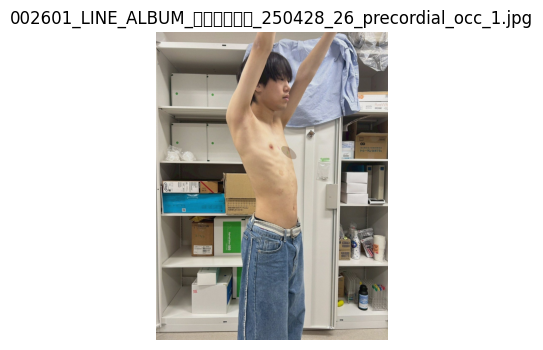

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12371 (\N{HIRAGANA LETTER KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12418 (\N{HIRAGANA LETTER MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/

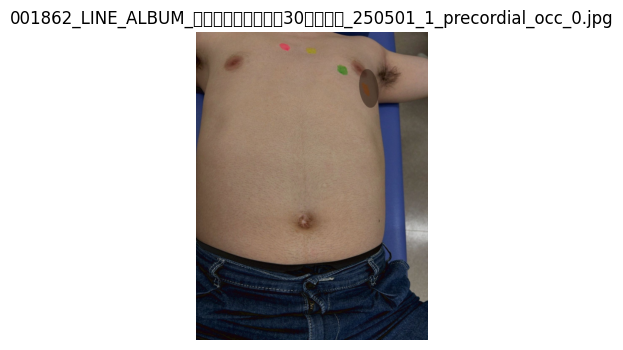

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12367 (\N{HIRAGANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20596 (\N{CJK UNIFIED IDEOGRAPH-5074}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


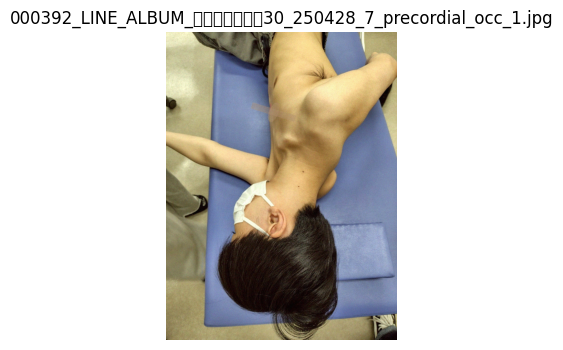

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12388 (\N{HIRAGANA LETTER TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12416 (\N{HIRAGANA LETTER MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12513 (\N{KATAKANA LETTER ME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

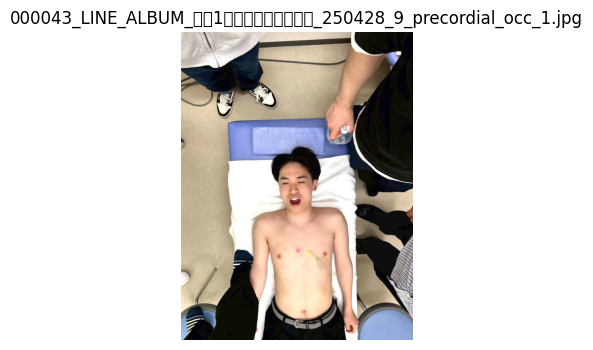

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12381 (\N{HIRAGANA LETTER SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


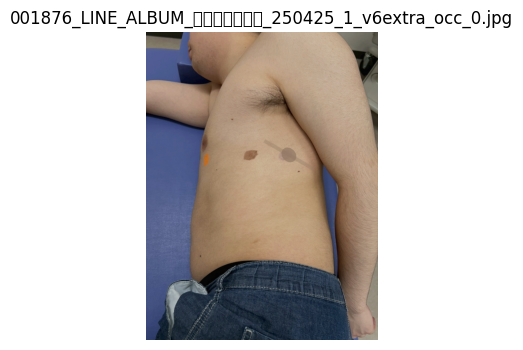

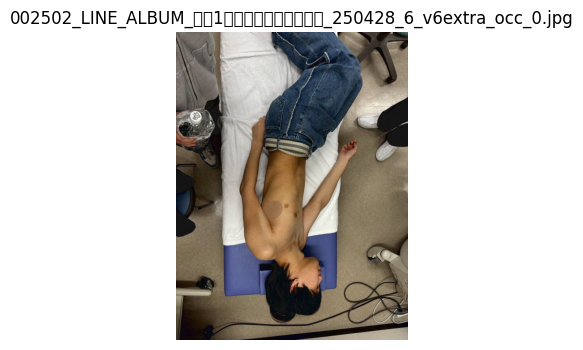

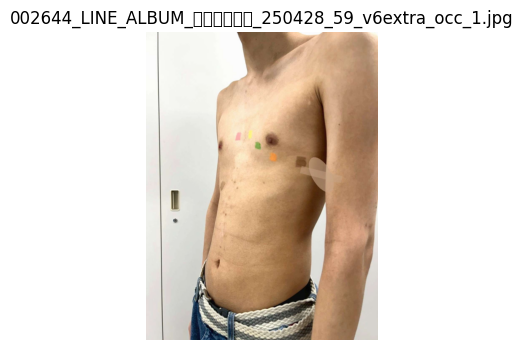

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12373 (\N{HIRAGANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32972 (\N{CJK UNIFIED IDEOGRAPH-80CC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

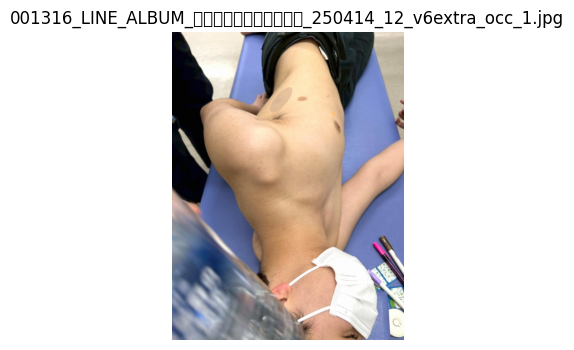

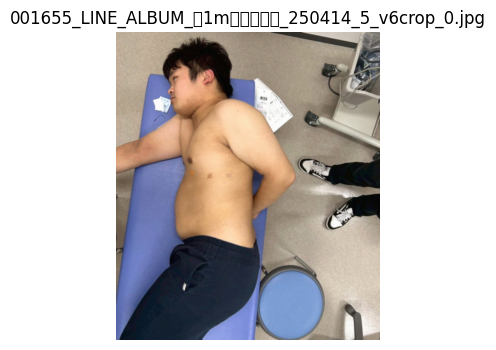

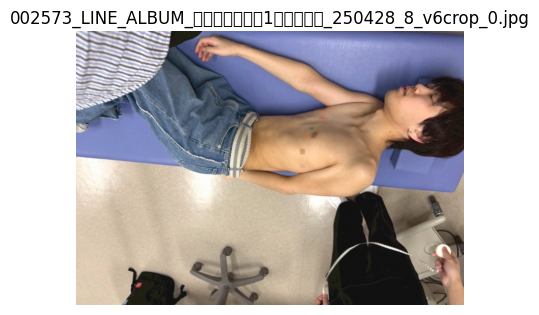

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30333 (\N{CJK UNIFIED IDEOGRAPH-767D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


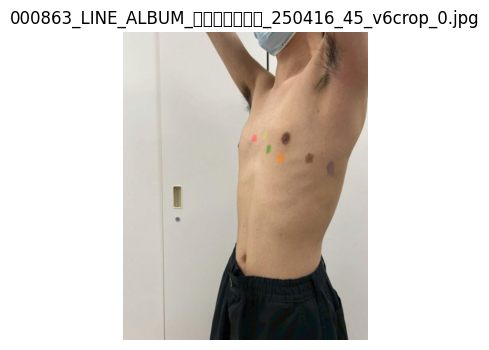

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21336 (\N{CJK UNIFIED IDEOGRAPH-5358}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


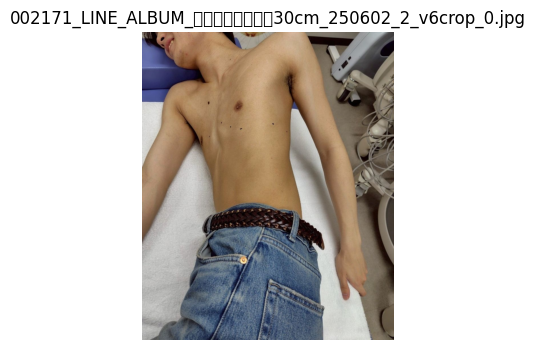

In [14]:
# セル10: 拡張画像の確認表示
# V1〜V6遮蔽・V6追加遮蔽・cropの見た目を数枚確認する。Colab上で表示されます。
import matplotlib.pyplot as plt

samples = list((AUG_ROOT/'images'/'train').glob('*_precordial_occ_*.jpg'))[:4] + list((AUG_ROOT/'images'/'train').glob('*_v6extra_occ_*.jpg'))[:4] + list((AUG_ROOT/'images'/'train').glob('*_v6crop_*.jpg'))[:4]
print("samples:", len(samples))
for p in samples[:12]:
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5,4))
    plt.imshow(img)
    plt.title(p.name)
    plt.axis('off')
    plt.show()


In [22]:
# セル11: fresh start学習用の共通関数
# ここから下は「途中checkpointからの追加学習」をしない。
# 各runごとに YOLO(PRETRAINED_POSE_MODEL) または YOLO("yolo11s-pose.pt") から新規に開始する。

from ultralytics import YOLO
from pathlib import Path
from datetime import datetime

PROJECT_DIR = Path("/content/pose_train_fresh")
RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# 実行する学習を選ぶ。時間がない場合は RUN_AUGMENTED だけ True でよい。
RUN_BASELINE  = True   # 元データのみでfresh start学習
RUN_AUGMENTED = True   # V1〜V6遮蔽＋V6補強データでfresh start学習

# モデルサイズ比較をしたい場合だけ追加する。
# まずは [PRETRAINED_POSE_MODEL] のみ推奨。余力があれば "yolo11s-pose.pt" を追加。
MODEL_CANDIDATES = [PRETRAINED_POSE_MODEL]
# MODEL_CANDIDATES = ["yolo11n-pose.pt", "yolo11s-pose.pt"]


def train_fresh(model_weight: str, data_yaml: Path, run_name: str, batch: int = BATCH):
    """事前学習済みpose weightからfresh startで学習する。

    注意:
    - last.ptは読み込まない。
    - resume=Falseを明示する。
    - run名にtimestampを付け、過去runと混ざらないようにする。
    - exist_ok=Falseにして、同名runを上書きしない。
    """
    print("=" * 80)
    print(f"Fresh training start")
    print(f"model_weight: {model_weight}")
    print(f"data_yaml   : {data_yaml}")
    print(f"run_name    : {run_name}")
    print("=" * 80)

    model = YOLO(model_weight)  # ここが重要。checkpointではなく、毎回pretrained pose modelから開始。

    results = model.train(
        data=str(data_yaml),
        imgsz=IMGSZ,
        epochs=EPOCHS,
        batch=batch,
        lr0=LR0,
        project=str(PROJECT_DIR),
        name=run_name,
        exist_ok=False,
        resume=False,
        pretrained=True,
        amp=True,

        # 医学的位置関係を壊しやすいaugmentationは切る
        fliplr=0.0,
        flipud=0.0,
        mosaic=0.0,
        mixup=0.0,
        copy_paste=0.0,
        perspective=0.0,
        shear=0.0,

        # 位置推定を壊しにくい範囲の軽いaugmentationだけ残す
        degrees=3,
        translate=0.03,
        scale=0.10,
        hsv_h=0.0,
        hsv_s=0.15,
        hsv_v=0.20,

        # 学習ログ管理
        plots=True,
        save=True,
        save_period=-1,
        verbose=True,
    )

    best_path = PROJECT_DIR / run_name / "weights" / "best.pt"
    last_path = PROJECT_DIR / run_name / "weights" / "last.pt"
    print(f"best.pt: {best_path}")
    print(f"last.pt: {last_path}")
    return str(best_path), str(last_path), results


In [23]:
# セル12: fresh startで学習を実行
# augmented modelを本命にする。baselineは比較用。

TRAINED_MODELS = {}

for weight in MODEL_CANDIDATES:
    model_tag = Path(weight).stem.replace("-pose", "")  # 例: yolo11n
    effective_batch = BATCH
    if "yolo11s" in weight:
        effective_batch = max(4, BATCH // 2)
    if "yolo11m" in weight:
        effective_batch = max(2, BATCH // 4)

    if RUN_BASELINE:
        run_name = f"{RUN_STAMP}_{model_tag}_baseline_original_img{IMGSZ}"
        best, last, _ = train_fresh(
            model_weight=weight,
            data_yaml=BASE_ROOT / "data.yaml",
            run_name=run_name,
            batch=effective_batch,
        )
        TRAINED_MODELS[f"{model_tag}_baseline"] = best

    if RUN_AUGMENTED:
        run_name = f"{RUN_STAMP}_{model_tag}_precordialMask_v6aug_img{IMGSZ}"
        best, last, _ = train_fresh(
            model_weight=weight,
            data_yaml=AUG_ROOT / "data.yaml",
            run_name=run_name,
            batch=effective_batch,
        )
        TRAINED_MODELS[f"{model_tag}_augmented"] = best

print("\n学習済みbest.pt一覧")
for k, v in TRAINED_MODELS.items():
    print(f"{k}: {v}")


Fresh training start
model_weight: yolo11n-pose.pt
data_yaml   : /content/pose_data_base/data.yaml
run_name    : 20260425_073528_yolo11n_baseline_original_img512
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pose_data_base/data.yaml, degrees=3, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.15, hsv_v=0.2, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mode

RuntimeError: 
  #ifdef __HIPCC__
  #define ERROR_UNSUPPORTED_CAST ;
  // corresponds to aten/src/ATen/native/cuda/thread_constants.h
  #define CUDA_OR_ROCM_NUM_THREADS 256
  // corresponds to aten/src/ATen/cuda/detail/OffsetCalculator.cuh
  #define MAX_DIMS 16
  #ifndef __forceinline__
  #define __forceinline__ inline __attribute__((always_inline))
  #endif
  #else
  #define ERROR_UNSUPPORTED_CAST __trap();
  #define CUDA_OR_ROCM_NUM_THREADS 128
  #define MAX_DIMS 25
  #endif
  #define POS_INFINITY __int_as_float(0x7f800000)
  #define INFINITY POS_INFINITY
  #define NEG_INFINITY __int_as_float(0xff800000)
  #define NAN __int_as_float(0x7fffffff)

  typedef long long int int64_t;
  typedef unsigned int uint32_t;
  typedef signed char int8_t;
  typedef unsigned char uint8_t;  // NOTE: this MUST be "unsigned char"! "char" is equivalent to "signed char"
  typedef short int16_t;
  typedef unsigned short uint16_t;
  typedef unsigned long long uint64_t;
  static_assert(sizeof(int64_t) == 8, 

## 使い方の要点

- V6が見えるデータは、ファイル名ではなくYOLO-PoseラベルのV6 visibilityで自動判定しています。
- 単純マスク遮蔽はV5/V6だけでなく、V1〜V6の見えている点のいずれかに適用します。
- V6あり画像には、追加でV6を優先した遮蔽と軽度cropを加えます。
- 拡張画像はtrainにだけ追加します。val/testに拡張画像を混ぜると評価が過大になります。
- 遮蔽・ノイズ拡張では座標を動かしていないので、ラベルはそのままコピーしています。
- crop拡張では座標変換をしています。V6だけの極端なcropではなく、元画像の78%以上を残す軽いcropに制限しています。
- 左右反転、mosaic、mixup、copy-paste、強いperspectiveは切っています。V1〜V6の医学的位置関係を壊すためです。
